#**1) INSTALL LIBRARIES**

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost

#**2) DATASET LOAD + BASIC CHECKING**

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("heart.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nTarget Distribution:")
print(df["target"].value_counts())

First 5 Rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

Dataset Shape:
(303, 14)

Column Names:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope     

#3) DATA PREPROCESSING

In [3]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:")
print(df.shape)

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Separate features and target
X = df.drop("target", axis=1)
y = df["target"]

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.head())

Dataset shape after removing duplicates:
(302, 14)

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Features:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Target:
0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64


#**4) EDA/GRAPHS**

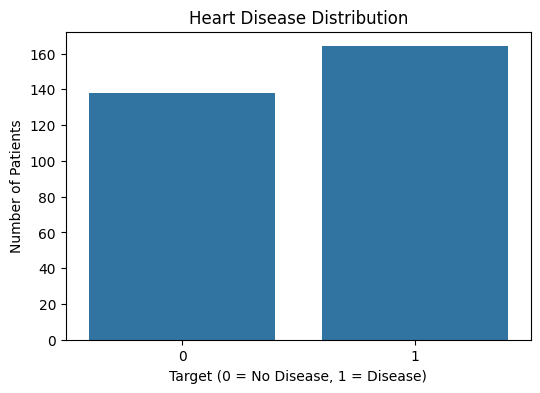

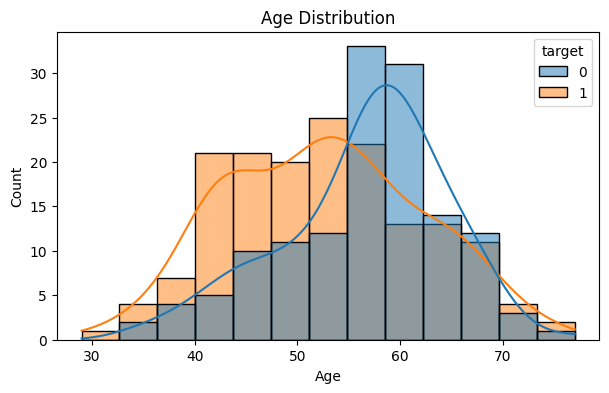

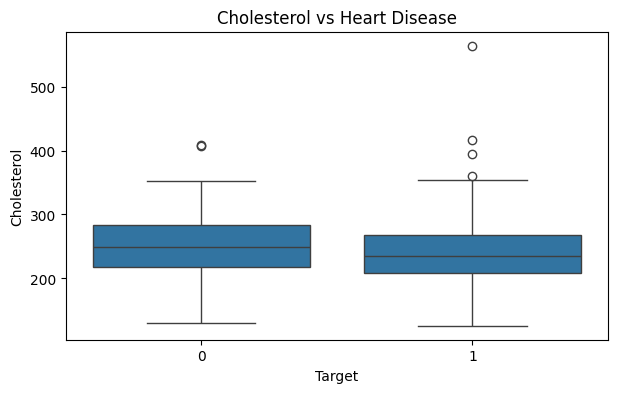

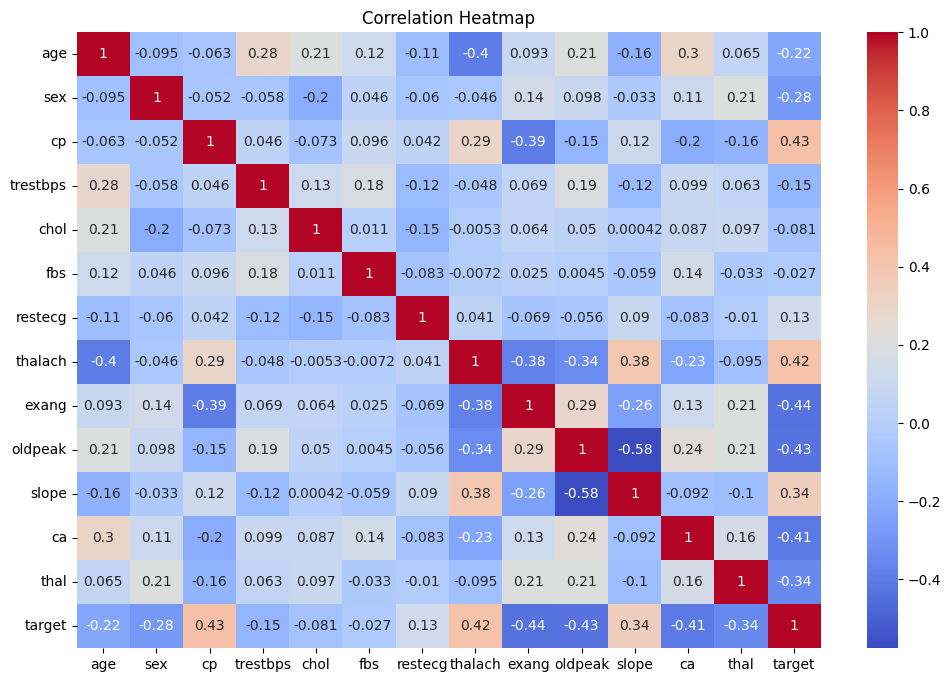

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target distribution
plt.figure(figsize=(6, 4))

sns.countplot(x="target", data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Number of Patients")

plt.show()


# Age distribution
plt.figure(figsize=(7, 4))

sns.histplot(
    data=df,
    x="age",
    hue="target",
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()


# Cholesterol vs Disease
plt.figure(figsize=(7, 4))

sns.boxplot(
    x="target",
    y="chol",
    data=df
)

plt.title("Cholesterol vs Heart Disease")
plt.xlabel("Target")
plt.ylabel("Cholesterol")

plt.show()


# Correlation heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

#**5) TRAIN TEST SPLIT + SCALING**

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = df.drop("target", axis=1)
y = df["target"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Training data: (241, 13)
Testing data: (61, 13)
Scaling completed!


#**6) LOGISTIC REGRESSION**

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Create model
model = LogisticRegression(max_iter=1000)

# Train
model.fit(X_train_scaled, y_train)

# Prediction
y_pred = model.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:",
      round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Logistic Regression Accuracy: 78.69 %

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.68      0.75        28
           1       0.76      0.88      0.82        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.78        61


Confusion Matrix:
[[19  9]
 [ 4 29]]


#**7) SVM**

In [7]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# Create SVM model
model = SVC(
    kernel="rbf",
    probability=True
)

# Train
model.fit(X_train_scaled, y_train)

# Prediction
y_pred = model.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("SVM Accuracy:",
      round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

SVM Accuracy: 83.61 %

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.71      0.80        28
           1       0.79      0.94      0.86        33

    accuracy                           0.84        61
   macro avg       0.85      0.83      0.83        61
weighted avg       0.85      0.84      0.83        61



#8) RANDOM FOREST

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# Create model
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:",
      round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Random Forest Accuracy: 80.33 %

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.64      0.75        28
           1       0.76      0.94      0.84        33

    accuracy                           0.80        61
   macro avg       0.83      0.79      0.79        61
weighted avg       0.82      0.80      0.80        61



#9) XGBOOST

In [9]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# Create XGBoost model
model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

# Train
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("XGBoost Accuracy:",
      round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

XGBoost Accuracy: 77.05 %

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.68      0.73        28
           1       0.76      0.85      0.80        33

    accuracy                           0.77        61
   macro avg       0.77      0.76      0.77        61
weighted avg       0.77      0.77      0.77        61



#**10) MODEL ACCURACY OF 4 MODELS TOGETHER**

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score


# Models
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "SVM":
        SVC(
            probability=True,
            kernel="rbf"
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.05,
            random_state=42,
            eval_metric="logloss"
        )
}


results = {}


# Train models
for name, model in models.items():

    if name in ["Logistic Regression", "SVM"]:

        model.fit(
            X_train_scaled,
            y_train
        )

        prediction = model.predict(
            X_test_scaled
        )

    else:

        model.fit(
            X_train,
            y_train
        )

        prediction = model.predict(
            X_test
        )

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    results[name] = accuracy


# Print results
print("\nMODEL ACCURACY")
print("=" * 40)

for name, accuracy in results.items():

    print(
        name,
        ":",
        round(accuracy * 100, 2),
        "%"
    )


MODEL ACCURACY
Logistic Regression : 78.69 %
SVM : 83.61 %
Random Forest : 80.33 %
XGBoost : 77.05 %


#**11) MODEL ACCURACY GRAPH**

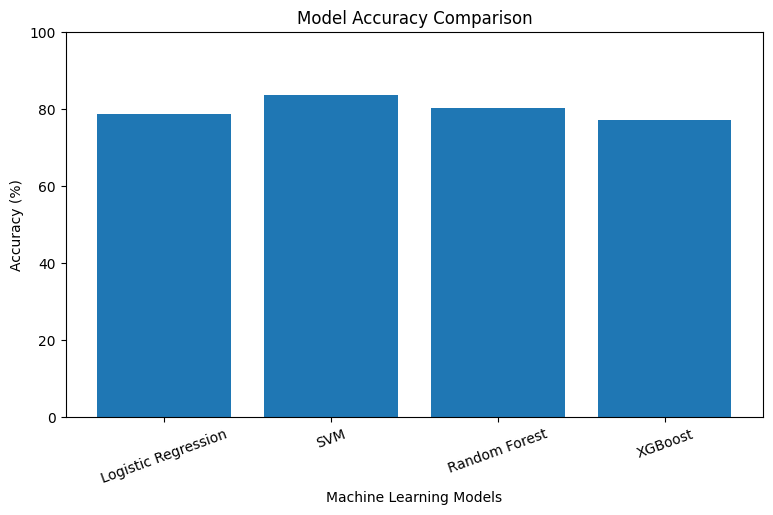

In [11]:
import matplotlib.pyplot as plt

names = list(results.keys())

accuracies = [
    value * 100
    for value in results.values()
]

plt.figure(figsize=(9, 5))

plt.bar(
    names,
    accuracies
)

plt.title("Model Accuracy Comparison")

plt.xlabel("Machine Learning Models")

plt.ylabel("Accuracy (%)")

plt.ylim(0, 100)

plt.xticks(rotation=20)

plt.show()

#**12) PATIENT DISEASE PREDICTION**

In [12]:
# Random Forest model
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train
model.fit(X_train, y_train)


# Patient data
patient = pd.DataFrame([{

    "age": 55,
    "sex": 1,
    "cp": 1,
    "trestbps": 130,
    "chol": 250,
    "fbs": 0,
    "restecg": 1,
    "thalach": 150,
    "exang": 0,
    "oldpeak": 1.0,
    "slope": 2,
    "ca": 0,
    "thal": 2

}])


# Prediction
prediction = model.predict(patient)

probability = model.predict_proba(patient)[0][1]


print("================================")
print("HEART DISEASE PREDICTION")
print("================================")

print(
    "Disease Probability:",
    round(probability * 100, 2),
    "%"
)


if prediction[0] == 1:

    print("Result: Disease Risk Detected")

else:

    print("Result: No Disease Detected")

HEART DISEASE PREDICTION
Disease Probability: 91.5 %
Result: Disease Risk Detected
